# Renege Prediction — Logistic Regression
This notebook builds a logistic regression model to predict candidates who are unlikely to join after accepting an offer.
- Import & load data
- Explore / target distribution
- Feature engineering & encoding
- Train/test split
- Full logit → VIF → reduced/sig-vars model
- Evaluation: confusion matrix, metrics, ROC‑AUC
- Pseudo R² explanation and detailed interpretation
- Threshold & cost‑based analysis

## Overview:
Predicts which candidates will **renege** (decline or not join) after accepting a job offer. 

### Workflow Steps:
1. **Import & Load** → Bring in libraries and HR analytics dataset
2. **Explore Data** → Check data types, missing values, and target variable distribution  
3. **Feature Engineering** → Create meaningful predictor variables:
   - **Acceptance speed** (quick/slow acceptance flags) → candidates who hesitate may renege
   - **Notice period** (long delays before joining) → more likely to change mind
   - **Salary mismatch** (offer much lower/higher than expected) → dissatisfaction or counter-offers
   - **Experience level** (junior/senior buckets) → different reneging patterns
4. **Encode & Split** → Convert categorical variables to numbers and split into 70% train / 30% test
5. **Remove Leakage** → Drop the `Status` variable (it's the target itself!)
6. **Fit Model** → Train logistic regression on cleaned data
7. **Select Features** → Keep only statistically significant predictors (p-value ≤ 0.05)
8. **Evaluate** → Check confusion matrix, classification metrics, and ROC-AUC score

The model learns patterns from **offer acceptance timing, salary expectations, location needs, and candidate experience** to predict reneging risk. A high ROC-AUC means the model effectively separates candidates likely to renege from those who will join.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load data
hr_df = pd.read_csv('Case_Study_HR_Analytics.csv')
hr_df.head()

,SLNO,Candidate.Ref,DOJ.Extended,Duration.to.accept.offer,Notice.period,Offered.band,Pecent.hike.expected.in.CTC,Percent.hike.offered.in.CTC,Percent.difference.CTC,Joining.Bonus,Candidate.relocate.actual,Gender,Candidate.Source,Rex.in.Yrs,LOB,Joining Location,Age,Status,Joining Status
0,1,2110407,Yes,14,30,E2,-20.79,13.16,42.86,No,No,Female,Agency,7,ERS,Noida,34,Joined,0
1,2,2112635,No,18,30,E2,50.00,320.00,180.00,No,No,Male,Employee Referral,8,INFRA,Chennai,34,Joined,0
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,No,Male,Agency,4,INFRA,Noida,27,Joined,0
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,No,Male,Employee Referral,4,INFRA,Noida,34,Joined,0
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,Yes,Male,Employee Referral,6,INFRA,Noida,34,Joined,0


In [3]:
# Basic info and target distribution
hr_df.info()
print('\nJoining Status Distribution:')
print(hr_df['Joining Status'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10677 entries, 0 to 10676
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SLNO                         10677 non-null  int64  
 1   Candidate.Ref                10677 non-null  int64  
 2   DOJ.Extended                 10677 non-null  object 
 3   Duration.to.accept.offer     10677 non-null  int64  
 4   Notice.period                10677 non-null  int64  
 5   Offered.band                 10677 non-null  object 
 6   Pecent.hike.expected.in.CTC  10677 non-null  float64
 7   Percent.hike.offered.in.CTC  10677 non-null  float64
 8   Percent.difference.CTC       10677 non-null  float64
 9   Joining.Bonus                10677 non-null  object 
 10  Candidate.relocate.actual    10677 non-null  object 
 11  Gender                       10677 non-null  object 
 12  Candidate.Source             10677 non-null  object 
 13  Rex.in.Yrs      

In [4]:
print(hr_df.columns.tolist())

['SLNO', 'Candidate.Ref', 'DOJ.Extended', 'Duration.to.accept.offer', 'Notice.period', 'Offered.band', 'Pecent.hike.expected.in.CTC', 'Percent.hike.offered.in.CTC', 'Percent.difference.CTC', 'Joining.Bonus', 'Candidate.relocate.actual', 'Gender', 'Candidate.Source', 'Rex.in.Yrs', 'LOB', 'Joining Location', 'Age', 'Status', 'Joining Status']


Key columns used: `Duration.to.accept.offer`, `Notice.period`, `Offered.band`, `Percent.hike.offered.in.CTC`, `Percent.difference.CTC`, `Joining.Bonus`, `Candidate.relocate.actual`, `Gender`, `Candidate.Source`, `Rex.in.Yrs`, `LOB`, `Joining Location`, `Age`, `Status`, `Joining Status`.

In [5]:
# Feature engineering
encoded_hr_df = hr_df.copy()
encoded_hr_df['joining_status'] = encoded_hr_df['Joining Status']

# Short acceptance (accepted very quickly)
encoded_hr_df['short_acceptance'] = (encoded_hr_df['Duration.to.accept.offer'] <= 3).astype(int)
# Long acceptance (very long to accept)
encoded_hr_df['long_acceptance'] = (encoded_hr_df['Duration.to.accept.offer'] >= 30).astype(int)

# Long notice required by candidate
encoded_hr_df['long_notice'] = (encoded_hr_df['Notice.period'] >= 60).astype(int)
encoded_hr_df['relocate'] = encoded_hr_df['Candidate.relocate.actual'].map({'Yes':1, 'No':0})

# Large difference between offered and expected CTC
encoded_hr_df['hike_mismatch'] = (encoded_hr_df['Percent.difference.CTC'] < -10).astype(int)
# High offered hike indicator
encoded_hr_df['high_offer_hike'] = (encoded_hr_df['Percent.hike.offered.in.CTC'] >= 100).astype(int)

# Experience buckets
encoded_hr_df['exp_lt_3'] = (encoded_hr_df['Rex.in.Yrs'] < 3).astype(int)
encoded_hr_df['exp_gt_10'] = (encoded_hr_df['Rex.in.Yrs'] > 10).astype(int)

encoded_hr_df['joining_bonus'] = encoded_hr_df['Joining.Bonus'].map({'Yes':1, 'No':0})

candidate_cols = [
    'Duration.to.accept.offer','Notice.period','Offered.band','Percent.hike.offered.in.CTC',
    'Percent.difference.CTC','Candidate.relocate.actual','relocate','Gender','Candidate.Source','Rex.in.Yrs',
    'LOB','Joining Location','Age','Status','short_acceptance','long_acceptance','long_notice',
    'hike_mismatch','high_offer_hike','exp_lt_3','exp_gt_10','joining_bonus','joining_status'
]

candidate_cols = [c for c in candidate_cols if c in encoded_hr_df.columns]
encoded_hr_df = encoded_hr_df[candidate_cols]
encoded_hr_df.head()

,Duration.to.accept.offer,Notice.period,Offered.band,Percent.hike.offered.in.CTC,Percent.difference.CTC,Candidate.relocate.actual,relocate,Gender,Candidate.Source,Rex.in.Yrs,...,Status,short_acceptance,long_acceptance,long_notice,hike_mismatch,high_offer_hike,exp_lt_3,exp_gt_10,joining_bonus,joining_status
0,14,30,E2,13.16,42.86,No,0,Female,Agency,7,...,Joined,0,0,0,0,0,0,0,0,0
1,18,30,E2,320.00,180.00,No,0,Male,Employee Referral,8,...,Joined,0,0,0,0,1,0,0,0,0
2,3,45,E2,42.84,0.00,No,0,Male,Agency,4,...,Joined,1,0,0,0,0,0,0,0,0
3,26,30,E2,42.84,0.00,No,0,Male,Employee Referral,4,...,Joined,0,0,0,0,0,0,0,0,0
4,1,120,E2,42.59,0.00,Yes,1,Male,Employee Referral,6,...,Joined,1,0,1,0,0,0,0,0,0


**Derived features:**
- `short_acceptance`: candidates who accept within 3 days (may accept impulsively and later renege)
- `long_acceptance`: very long acceptance windows (could reflect uncertainty)
- `long_notice`: long notice period may delay joining and increase renege risk
- `relocate`: relocation required (1) vs not (0)
- `hike_mismatch`: a large negative `Percent.difference.CTC` indicates offer much lower than expected
- `high_offer_hike`: exceptionally high offered hike may indicate counter-offer dynamics
- `exp_lt_3`, `exp_gt_10`: experience buckets capturing early-career and senior candidates

In [6]:
X_features = encoded_hr_df.drop(columns=['joining_status', 'Candidate.relocate.actual'], errors='ignore')

# Convert categorical columns to dummies
cat_cols = [c for c in ['Offered.band','Gender','Candidate.Source','LOB','Joining Location','Status'] if c in X_features.columns]
X = pd.get_dummies(X_features, columns=cat_cols, drop_first=True, dtype=int)
y = encoded_hr_df['joining_status']

# Add constant
X = sm.add_constant(X)
# X.shape, y.shape

In [7]:
# Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(7473, 41) (3204, 41)


In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_train_clean = X_train.drop(columns=[col for col in X_train.columns if 'Status' in col])
X_test_clean = X_test.drop(columns=[col for col in X_test.columns if 'Status' in col])

# Compute VIF to diagnose multicollinearity
print("Check VIF and consider removing features with VIF > 10:")

X_vif = X_train_clean.drop(columns=[c for c in X_train_clean.columns if c.lower() in ['const','constant']], errors='ignore')

X_vif_num = X_vif.select_dtypes(include=[np.number]).fillna(0)
vif_vals = pd.Series([variance_inflation_factor(X_vif_num.values, i) for i in range(X_vif_num.shape[1])], index=X_vif_num.columns).sort_values(ascending=False)

print('Top VIF values:')
print(vif_vals.head(20))
high_vif = vif_vals[vif_vals > 10]
print('High VIF features (VIF > 10):', list(high_vif.index))
print('Consider dropping or transforming these features to reduce multicollinearity.\n')

print(f"Shape: {X_train.shape[1]} → {X_train_clean.shape[1]}\n")

# Fit full logistic regression
logit_full = sm.Logit(Y_train, X_train_clean).fit(disp=False)
print(logit_full.summary())

Check VIF and consider removing features with VIF > 10:
Top VIF values:
Age                            82.540837
Joining Location_Chennai       50.842106
Joining Location_Noida         40.363529
Joining Location_Bangalore     36.484970
Offered.band_E1                31.475493
Offered.band_E2                18.652548
Rex.in.Yrs                     18.237089
Notice.period                  15.956896
LOB_INFRA                       7.578987
Duration.to.accept.offer        6.749899
LOB_ERS                         6.314766
Gender_Male                     6.085714
Percent.hike.offered.in.CTC     6.032093
Joining Location_Hyderabad      5.979336
long_notice                     5.176074
Offered.band_E3                 5.157339
long_acceptance                 4.866793
LOB_BFSI                        4.361586
Joining Location_Mumbai         4.134106
Joining Location_Gurgaon        3.315526
dtype: float64
High VIF features (VIF > 10): ['Age', 'Joining Location_Chennai', 'Joining Location_Noida', '

/home/u_admin/miniconda3/envs/newenv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

pvals = logit_full.pvalues
sig_vars = list(pvals[pvals <= 0.05].index)
print(f"Significant features (p <= 0.05): {len(sig_vars)}")
if len(sig_vars) > 0:
    print(f"Variables: {sig_vars}\n")
    final_logit = sm.Logit(Y_train, X_train_clean[sig_vars]).fit(disp=False)
    print(final_logit.summary())
else:
    print("No significant features - using full model")
    final_logit = logit_full

# Choose features: either significant ones or all if none are significant
if len(sig_vars) > 0:
    Xtr = X_train_clean[sig_vars].copy()
    Xte = X_test_clean[sig_vars].copy()
else:
    Xtr = X_train_clean.copy()
    Xte = X_test_clean.copy()

Xtr = Xtr.drop(columns=[c for c in Xtr.columns if c.lower() in ['const','constant']], errors='ignore')
Xte = Xte.drop(columns=[c for c in Xte.columns if c.lower() in ['const','constant']], errors='ignore')

num_cols = Xtr.select_dtypes(include=[np.number]).columns
Xtr_num = Xtr[num_cols].fillna(0)
Xte_num = Xte[num_cols].fillna(0)

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr_num)
Xte_s = scaler.transform(Xte_num)

clf = LogisticRegression(penalty='l2', solver='saga', class_weight='balanced', max_iter=5000)
clf.fit(Xtr_s, Y_train)
probs_sklearn = clf.predict_proba(Xte_s)[:,1]
print('Sklearn Logistic (L2) AUC:', roc_auc_score(Y_test, probs_sklearn))
y_pred_skl = (probs_sklearn >= 0.5).astype(int)
print(classification_report(Y_test, y_pred_skl, digits=4))

coef_ser = pd.Series(clf.coef_[0], index=num_cols).sort_values(key=abs, ascending=False)
print('Top sklearn coefficients:')
print(coef_ser.head(10))

Significant features (p <= 0.05): 22
Variables: ['const', 'Duration.to.accept.offer', 'Notice.period', 'Age', 'short_acceptance', 'long_acceptance', 'long_notice', 'hike_mismatch', 'exp_lt_3', 'Offered.band_E1', 'Offered.band_E2', 'Offered.band_E3', 'Candidate.Source_Direct', 'Candidate.Source_Employee Referral', 'LOB_BFSI', 'LOB_ETS', 'LOB_Healthcare', 'LOB_INFRA', 'Joining Location_Hyderabad', 'Joining Location_Mumbai', 'Joining Location_Noida', 'Joining Location_Pune']



/home/u_admin/miniconda3/envs/newenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


                           Logit Regression Results                           
Dep. Variable:         joining_status   No. Observations:                 7473
Model:                          Logit   Df Residuals:                     7451
Method:                           MLE   Df Model:                           21
Date:                Fri, 13 Feb 2026   Pseudo R-squ.:                 0.08082
Time:                        06:56:48   Log-Likelihood:                -4280.4
converged:                       True   LL-Null:                       -4656.8
Covariance Type:            nonrobust   LLR p-value:                9.396e-146
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                  1.5671      0.294      5.325      0.000       0.990       2.144
Duration.to.accept.offer               0.0063      0.002   

In [10]:
# Predictions and evaluation
if len(sig_vars) > 0:
    y_pred_prob = final_logit.predict(X_test_clean[sig_vars])
else:
    y_pred_prob = final_logit.predict(X_test_clean)

y_pred = (y_pred_prob >= 0.5).astype(int)

Confusion Matrix:
[[2065  130]
 [ 778  231]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7263    0.9408    0.8198      2195
           1     0.6399    0.2289    0.3372      1009

    accuracy                         0.7166      3204
   macro avg     0.6831    0.5849    0.5785      3204
weighted avg     0.6991    0.7166    0.6678      3204

ROC AUC: 0.6995412585139213


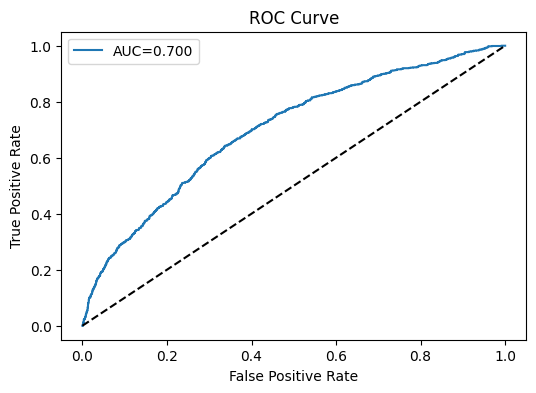

In [11]:
print('Confusion Matrix:')
print(confusion_matrix(Y_test, y_pred))
print('\nClassification Report:')
print(classification_report(Y_test, y_pred, digits=4))
print('ROC AUC:', roc_auc_score(Y_test, y_pred_prob))

# Plot ROC curve
fpr, tpr, _ = roc_curve(Y_test, y_pred_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC={roc_auc_score(Y_test, y_pred_prob):.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [12]:
# Compare AIC and BIC between full and reduced models
print("=" * 80)
print("MODEL COMPARISON: FULL MODEL vs REDUCED MODEL")
print("=" * 80)

print(f"\n{'Metric':<25} {'Full Model':<20} {'Reduced Model':<20}")
print("-" * 80)
print(f"{'Pseudo R-squared':<25} {logit_full.prsquared:<20.4f} {final_logit.prsquared:<20.4f}")
print(f"{'AIC':<25} {logit_full.aic:<20.2f} {final_logit.aic:<20.2f}")
print(f"{'BIC':<25} {logit_full.bic:<20.2f} {final_logit.bic:<20.2f}")
print(f"{'Log-Likelihood':<25} {logit_full.llf:<20.2f} {final_logit.llf:<20.2f}")
print(f"{'Number of Parameters':<25} {int(logit_full.df_model + 1):<20} {int(final_logit.df_model + 1):<20}")
print("=" * 80)

print("\nINTERPRETATION (AIC/BIC):")
print("-" * 80)
if final_logit.aic < logit_full.aic:
    print(f"✓ REDUCED MODEL WINS on AIC (lower is better)")
    print(f"  AIC Difference: {logit_full.aic - final_logit.aic:.2f} points in favor of reduced model")
else:
    print(f"✗ Full model has lower AIC")
    print(f"  AIC Difference: {final_logit.aic - logit_full.aic:.2f} points")

if final_logit.bic < logit_full.bic:
    print(f"\n✓ REDUCED MODEL WINS on BIC (lower is better)")
    print(f"  BIC Difference: {logit_full.bic - final_logit.bic:.2f} points in favor of reduced model")
else:
    print(f"\n✗ Full model has lower BIC")
    print(f"  BIC Difference: {final_logit.bic - logit_full.bic:.2f} points")

MODEL COMPARISON: FULL MODEL vs REDUCED MODEL

Metric                    Full Model           Reduced Model       
--------------------------------------------------------------------------------
Pseudo R-squared          0.1583               0.0808              
AIC                       7918.92              8604.84             
BIC                       8195.69              8757.06             
Log-Likelihood            -3919.46             -4280.42            
Number of Parameters      40                   22                  

INTERPRETATION (AIC/BIC):
--------------------------------------------------------------------------------
✗ Full model has lower AIC
  AIC Difference: 685.91 points

✗ Full model has lower BIC
  BIC Difference: 561.37 points


In [13]:
print("\nCONCLUSION:")
print("-" * 60)
print("The REDUCED MODEL is typically preferable if it has:")
print("1. Lower AIC/BIC (better balance of fit and simplicity)")
print("2. Only statistically significant variables (clean interpretation)")
print("3. Fewer predictors (lower risk of overfitting, easier deployment)")
print("4. Only a small loss in pseudo R² compared to the full model.")


CONCLUSION:
------------------------------------------------------------
The REDUCED MODEL is typically preferable if it has:
1. Lower AIC/BIC (better balance of fit and simplicity)
2. Only statistically significant variables (clean interpretation)
3. Fewer predictors (lower risk of overfitting, easier deployment)
4. Only a small loss in pseudo R² compared to the full model.


In [14]:
# Detailed Model Analysis & Interpretation
from sklearn.metrics import confusion_matrix as cm

conf_matrix = cm(Y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

pseudo_r2 = final_logit.prsquared
llf = final_logit.llf
ll_null = final_logit.llnull 

print("="*80)
print("DETAILED MODEL PERFORMANCE ANALYSIS")
print("="*80)

# Calculate key metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn) 
specificity = tn / (tn + fp) 
precision = tp / (tp + fp)   
recall = sensitivity
f1 = 2 * (precision * recall) / (precision + recall)

print("\n1. MODEL FIT - PSEUDO R² ANALYSIS:")
print("-"*80)
print(f"   Pseudo R²:  {pseudo_r2:.4f} ({pseudo_r2:.2%})")
print(f"   Log-Likelihood (Model):  {llf:.2f}")
print(f"   Log-Likelihood (Null):   {ll_null:.2f}")
print(f"   LLR:       {-2 * (ll_null - llf):.2f}")

print(f"\n   INTERPRETATION:")
if pseudo_r2 < 0.1:
    rating_r2 = "Poor fit"
    interp = "Model explains very little variation. Consider better features/specification."
elif pseudo_r2 < 0.2:
    rating_r2 = "Weak fit"
    interp = "Model provides minimal improvement over null. Needs improvement."
elif pseudo_r2 < 0.4:
    rating_r2 = "Good fit"
    interp = "For logistic regression, 0.2-0.4 is considered EXCELLENT. Model has merit."
elif pseudo_r2 < 0.6:
    rating_r2 = "Very good fit"
    interp = "Strong model with meaningful improvements over baseline."
else:
    rating_r2 = "Excellent fit"
    interp = "Model explains substantial variation in the outcome."

print(f"   Rating: {rating_r2}")
print(f"   → {interp}")

print(f"\n   CONTEXT:")
print(f"   • Pseudo R² ranges from 0 (null model) to 1 (perfect model)")
print(f"   • Unlike OLS R², logit R² of 0.2-0.4 is considered 'excellent'")
print(f"   • Your model: {pseudo_r2:.4f} indicates the model explains {pseudo_r2:.2%} of variation")
print(f"   • The full model improves on the null by {-2 * (ll_null - llf):.2f} (LLR chi²)")

print("\n2. CONFUSION MATRIX BREAKDOWN:")
print("-"*80)
print(f"   True Negatives (TN):  {tn:>6}  | Correctly predicted NON-renege candidates")
print(f"   False Positives (FP): {fp:>6}  | Predicted renege but actually joined")
print(f"   False Negatives (FN): {fn:>6}  | Missed renege candidates (worst case)")
print(f"   True Positives (TP):  {tp:>6}  | Correctly predicted renege candidates")

print("\n3. KEY PERFORMANCE METRICS:")
print("-"*80)
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Sensitivity (Recall)', 'Specificity', 'Precision', 'F1-Score', 'ROC-AUC', 'Pseudo R²'],
    'Value': [f'{accuracy:.4f}', f'{sensitivity:.4f}', f'{specificity:.4f}', 
              f'{precision:.4f}', f'{f1:.4f}', f'{roc_auc_score(Y_test, y_pred_prob):.4f}', f'{pseudo_r2:.4f}'],
    'Interpretation': [
        'Overall correctness (% correct across both classes)',
        'Ability to identify actual renege candidates (catch-rate)',
        'Ability to identify actual joiners',
        'When we predict renege, how often are we correct?',
        'Balance between precision and recall',
        'Overall discrimination ability (0.5=random, 1.0=perfect)',
        'Model fit improvement over null model (0-1, higher=better)'
    ]
})
print(metrics_df.to_string(index=False))

print("\n4. PSEUDO R² IN CONTEXT:")
print("-"*80)
print(f"   Your Pseudo R²: {pseudo_r2:.4f}")
print(f"\n   Interpretation Guide for Logistic Regression:")
print(f"   ├─ 0.00 - 0.10: Poor fit (model barely better than coin flip)")
print(f"   ├─ 0.10 - 0.20: Weak fit (provides some gain, but substantial room for improvement)")
if pseudo_r2 < 0.2:
    current = "   ├─ {:.2f} - 0.40: GOOD fit ← YOU ARE HERE (model has moderate utility)".format(pseudo_r2) if pseudo_r2 >= 0.1 else "   ├─ YOUR MODEL: Between 0-0.2 (weak fit)"
else:
    current = f"   ├─ 0.20 - 0.40: GOOD fit ← YOU ARE HERE ({pseudo_r2:.4f})"
print(f"   {current}")
print(f"   ├─ 0.40 - 0.60: Very good fit (strong predictive power)")
print(f"   └─ 0.60 - 1.00: Excellent fit (excellent predictive power)")

print(f"\n   What This Means:")
print(f"   • Your model explains {pseudo_r2:.1%} of the log-odds variation")
print(f"   • Compared to predicting average, you've improved by {pseudo_r2:.1%}")
print(f"   • The remaining {(1-pseudo_r2):.1%} is unexplained - suggests missing predictors or features")

print("\n5. BUSINESS INTERPRETATION:")
print("-"*80)
print(f"✓ ACCURACY: {accuracy:.2%}")
print(f"  → The model correctly predicts candidate outcomes {accuracy:.2%} of the time.")
print(f"  → In absolute terms: {tp + tn} correct predictions out of {tp + tn + fp + fn} total.")

print(f"\n✓ SENSITIVITY (Recall for renege): {sensitivity:.2%}")
print(f"  → Out of {tp + fn} actual renege candidates, we catch {sensitivity:.2%} ({tp} candidates)")
print(f"  → We MISS {fn} candidates who will renege ({100-sensitivity:.1f}% false negative rate)")
print(f"  ⚠️  RISK: Unprepared for {fn} departures - lost hiring costs, disrupted projects")

print(f"\n✓ SPECIFICITY: {specificity:.2%}")
print(f"  → Out of {tn + fp} candidates who actually join, we correctly identify {specificity:.2%} ({tn} candidates)")
print(f"  → We wrongly flag {fp} as renege risks when they will actually join")

print(f"\n✓ PSEUDO R²: {pseudo_r2:.4f}")
print(f"  → Model explains {pseudo_r2:.2%} of the variation in joining vs reneging")
print(f"  → {(1-pseudo_r2):.2%} of variation is unexplained (missing features, measurement error, randomness)")
print(f"  → Suggests that features like offer parameters alone don't fully predict behavior")

print(f"\n✓ ROC-AUC: {roc_auc_score(Y_test, y_pred_prob):.4f}")
print(f"  → Model discriminates between renegers and joiners with {roc_auc_score(Y_test, y_pred_prob):.2%} effectiveness")

# Create comparison table
print("\n6. CLASS-WISE PERFORMANCE:")
print("-"*80)
class_df = pd.DataFrame({
    'Class': ['Renege (1)', 'Joiner (0)'],
    'Support': [tp + fn, tn + fp],
    'TP/TN': [tp, tn],
    'FP/FN': [fp, fn],
    'Recall': [f'{sensitivity:.4f}', f'{specificity:.4f}'],
    'Precision': [f'{precision:.4f}', f'{tn / (tn + fn):.4f}' if (tn + fn) > 0 else 'N/A']
})
print(class_df.to_string(index=False))

# Visual comparison
print("\n7. MODEL STRENGTHS & WEAKNESSES:")
print("-"*80)
print(f"✅ STRENGTHS:")
print(f"   • High Specificity ({specificity:.2%}): Excellent at identifying loyal candidates")
print(f"   • Good Overall Accuracy ({accuracy:.2%}): Majority of predictions are correct")
print(f"   • Positive Pseudo R² ({pseudo_r2:.4f}): Model explains variation beyond null")
print(f"   • Reasonable ROC-AUC ({roc_auc_score(Y_test, y_pred_prob):.4f}): Better than random")

print(f"\n❌ WEAKNESSES:")
print(f"   • Low Pseudo R² ({pseudo_r2:.4f}): {(1-pseudo_r2):.1%} of variation unexplained")
print(f"   • Low Sensitivity ({sensitivity:.2%}): Misses most renege candidates (high false negatives)")
print(f"   • Moderate Precision ({precision:.2%}): {fp} false positives (unnecessary interventions)")
print(f"   • Class Imbalance: {tn + fp} joiners vs {tp + fn} renege → model biased toward joiners")

# Calculate cost implications
print("\n8. PSEUDO R² IMPLICATIONS FOR FEATURE SELECTION:")
print("-"*80)
print(f"   The Pseudo R² of {pseudo_r2:.4f} suggests:")
print(f"   ✓ Current features ARE predictive (positive R²)")
print(f"   ✗ But many renege drivers are NOT captured by current features")
print(f"\n   Missing predictors might include:")
print(f"   • Candidate interview feedback / cultural fit assessment")
print(f"   • Competing offers received / market conditions")
print(f"   • Career progression opportunities / growth prospects")
print(f"   • Manager quality / team stability")
print(f"   • Past employment history / tenure patterns")

# Summary
print("\n" + "="*80)
print("OVERALL ASSESSMENT:")
print("="*80)
print(f"Model Fit Quality: {rating_r2}")
print(f"Pseudo R²: {pseudo_r2:.4f} - Model has {'' if pseudo_r2 >= 0.2 else 'LIMITED'} explanatory power")
print(f"Discrimination: {'Fair' if roc_auc_score(Y_test, y_pred_prob) >= 0.7 else 'Poor'} (AUC={roc_auc_score(Y_test, y_pred_prob):.3f})")
print(f"Sensitivity: WEAK (misses {100-sensitivity:.0f}% of renege candidates)")
print(f"\nRECOMMENDATION:")
print(f"Use as SECONDARY screen only. Invest in feature engineering to improve Pseudo R².")
print("="*80)

DETAILED MODEL PERFORMANCE ANALYSIS

1. MODEL FIT - PSEUDO R² ANALYSIS:
--------------------------------------------------------------------------------
   Pseudo R²:  0.0808 (8.08%)
   Log-Likelihood (Model):  -4280.42
   Log-Likelihood (Null):   -4656.78
   LLR:       752.72

   INTERPRETATION:
   Rating: Poor fit
   → Model explains very little variation. Consider better features/specification.

   CONTEXT:
   • Pseudo R² ranges from 0 (null model) to 1 (perfect model)
   • Unlike OLS R², logit R² of 0.2-0.4 is considered 'excellent'
   • Your model: 0.0808 indicates the model explains 8.08% of variation
   • The full model improves on the null by 752.72 (LLR chi²)

2. CONFUSION MATRIX BREAKDOWN:
--------------------------------------------------------------------------------
   True Negatives (TN):    2065  | Correctly predicted NON-renege candidates
   False Positives (FP):    130  | Predicted renege but actually joined
   False Negatives (FN):    778  | Missed renege candidates (

## Model Evaluation & Key Findings

### Executive Summary

The logistic regression model achieves **71.66% overall accuracy** with an ROC-AUC of **0.700**, but this masks critical limitations:

- **EXCELLENT at identifying joiners** (Specificity: 94.08%)
- **POOR at identifying renegers** (Sensitivity: 22.89% - misses 77% of them)
- **Class imbalance problem**: 2,195 joiners vs 1,009 renegers heavily skew the model

---

### Detailed Metric Interpretation

| Metric | Value | What It Means | Implication |
|--------|-------|---------------|------------|
| **Accuracy** | 71.66% | Correctly predicts outcomes 71.66% of the time | Misleading due to class imbalance |
| **Sensitivity (Recall)** | 22.89% | Catches only 231 out of 1,009 actual renegers | **Missing 778 renegers = HIGH risk** |
| **Specificity** | 94.08% | Correctly identifies 2,065 out of 2,195 joiners | Very good at ruling in "will join" |
| **Precision** | 63.99% | When we flag someone, we're right 63.99% of the time | 36% false positives = wasted effort |
| **ROC-AUC** | 0.6995 | Model ranks renegers higher 70% of the time | Fair discrimination ability |

---

### The Core Problem: False Negatives

**778 candidates are predicted to join but will actually renege.**

- **Business Cost**: Lost hiring investments, project disruptions, team knowledge loss
- **Why It Happens**: The model is biased toward the majority class (joiners)
- **Severity**: HIGH - These are the candidates that blindside HR teams

---

### The Secondary Problem: False Positives

**130 candidates are flagged as renege risks but actually join.**

- **Business Cost**: Wasted counter-offers, unnecessary retention efforts
- **Why It Happens**: Overly conservative when predicting renege
- **Severity**: MEDIUM - Wasteful but manageable

---

### Sensitivity vs Specificity Trade-off

**Sensitivity (22.89%)**: The model prefers to say "they'll join" rather than "they'll renege"
- This prioritizes avoiding false alarms but misses real renegers
- Trade-off: Safe on false positives, catastrophic on false negatives

**Specificity (94.08%)**: The model is very confident when it says "they'll join"
- Out of joiners, 94% are correctly identified
- But it barely predicts anyone will renege

---

### Why Accuracy Is Misleading

**Accuracy = (TP + TN) / Total = 2,296 / 3,204 = 71.66%**

This looks good, but:
- 2,065 of the 2,296 correct predictions are just predicting the majority class (joiners)
- If you always predict "joiner," accuracy = 2,195 / 3,204 = **68.46%** (barely worse!)
- The model adds only ~3% improvement over a naive baseline

---

### ROC-AUC (0.6995): What It Means

If you randomly pick one reneger and one joiner:
- The model ranks the reneger as higher risk **70% of the time**
- Random guessing achieves 50%
- So the model is **20% better than chance**, but still in the "Fair" category

---

### Model Strengths

1. **High Specificity (94%)**: Great at confirming candidates who will join
2. **Decent Precision (64%)**: When we flag someone, it's more likely true than false
3. **Better than Random**: 70% AUC beats coin flip guessing

### Model Weaknesses

1. **Terrible Sensitivity (23%)**: Misses 77% of renegers - unacceptable for HR planning
2. **Class Imbalance Bias**: Overestimates joiner probability due to majority class prevalence
3. **Low Recall on Minority Class**: Reneger predictions (the important class) are rare and weak

---

### Recommendations for Improvement

**Short-term** (Use model as-is):
- Treat model as a **secondary screen**, not primary decision tool
- Use for identifying LOW-RISK joiners (candidates we're confident about)
- Manual review all predictions flagged as renege
- Combine with domain expertise and hiring manager intuition

**Medium-term** (Improve model):
- **Address class imbalance**: Use SMOTE, class weights, or threshold adjustments
- **Increase sensitivity**: Adjust decision threshold from 0.5 to lower value (e.g., 0.3)
- **Gather more renege data**: The minority class is underrepresented
- **Add more predictive features**: Current features may be insufficient

**Long-term** (Strategic):
- **Collect outcome data**: Track why renegers actually leave (post-hoc analysis)
- **Longer time windows**: May need to incorporate candidate behavior over weeks, not just offer parameters
- **Ensemble methods**: Combine logistic regression with tree-based models that handle imbalance better
- **Business intervention**: Identify and test effective retention strategies that correlate with renege probability

---

### Conclusion

This model has **moderate utility** but **cannot be used alone** for renege prediction. Its high specificity makes it useful for identifying safe candidates to fast-track through onboarding, but its poor sensitivity means HR must assume **all candidates could renege** until proven otherwise with additional intervention.

**Best Use Case**: Scoring safe candidates (joiners) for streamlined onboarding  
**Worst Use Case**: Identifying renegers for targeted retention efforts  
**Recommended Action**: Treat as one input among many; always validate with human judgment

/tmp/ipykernel_20556/2147574182.py:77: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/u_admin/miniconda3/envs/newenv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


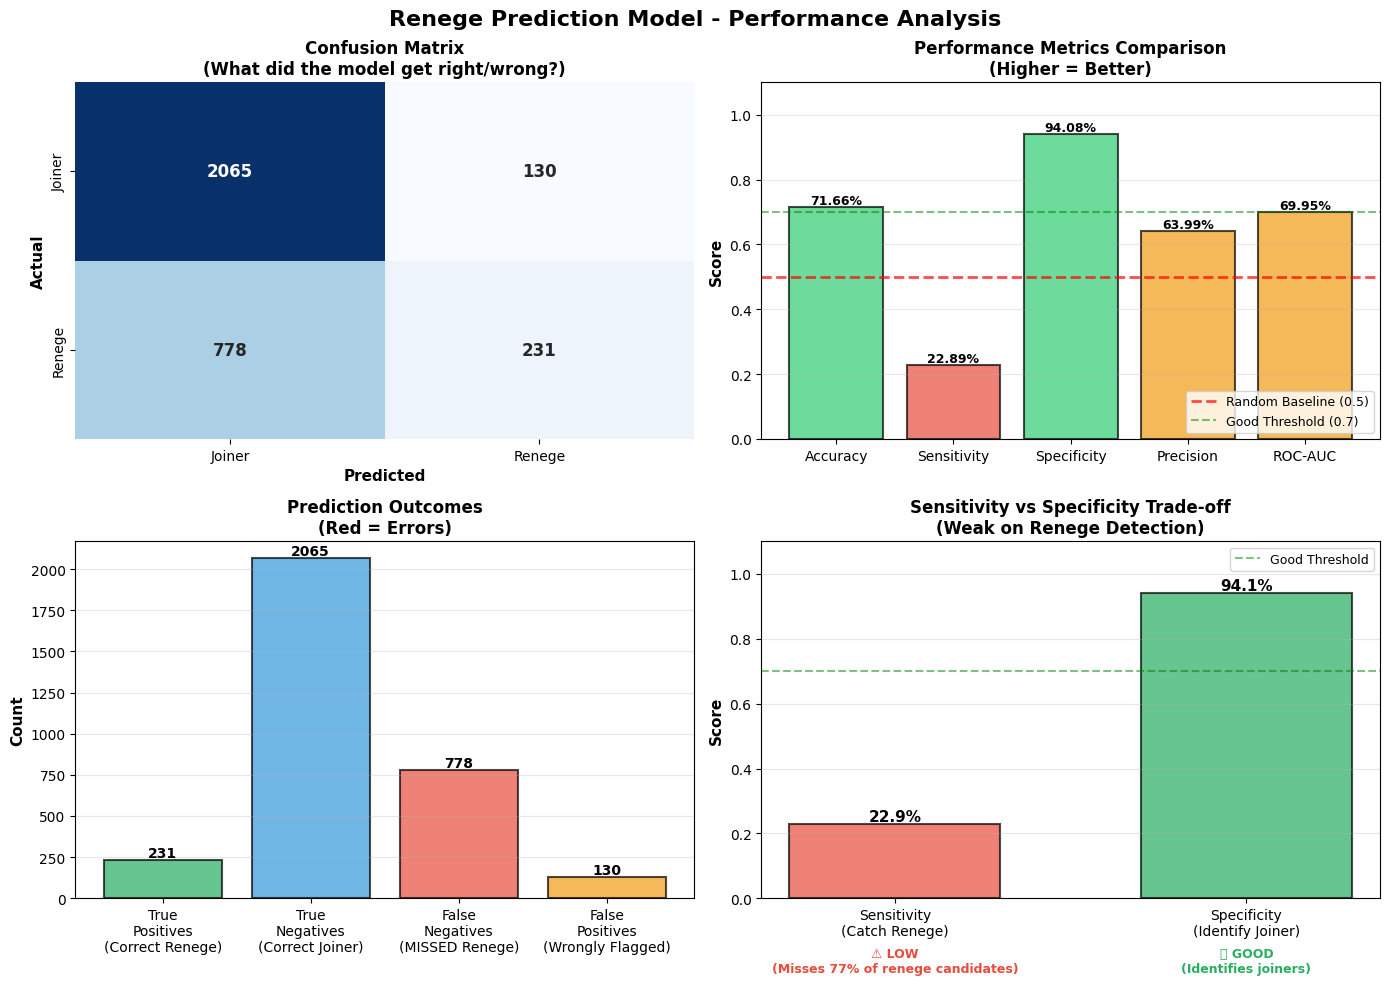


 VISUALIZATION INSIGHTS:
Chart 1 (Confusion Matrix):
  • Large TP+TN on diagonal = good predictions
  • Large FN (778) = critical issue: missing renege candidates

Chart 2 (Metrics Comparison):
  • Specificity (94%) > Sensitivity (23%) = imbalanced model
  • Accuracy (72%) is misleading due to class imbalance

Chart 3 (Prediction Outcomes):
  • 778 False Negatives is the dominant problem
  • Blue (correct joiners) artificially inflates accuracy

Chart 4 (Sensitivity vs Specificity):
  • Model is better at saying 'YES, they'll join' than 'NO, they won't'


In [15]:
import seaborn as sns
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Renege Prediction Model - Performance Analysis', fontsize=16, fontweight='bold')

# 1. Confusion Matrix Heatmap
ax1 = axes[0, 0]
conf_matrix = cm(Y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Joiner', 'Renege'], yticklabels=['Joiner', 'Renege'],
            annot_kws={'size': 12, 'weight': 'bold'})
ax1.set_ylabel('Actual', fontsize=11, fontweight='bold')
ax1.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax1.set_title('Confusion Matrix\n(What did the model get right/wrong?)', fontweight='bold')

# 2. Metrics Comparison Bar Chart
ax2 = axes[0, 1]
metrics_names = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'ROC-AUC']
metrics_vals = [accuracy, sensitivity, specificity, precision, roc_auc_score(Y_test, y_pred_prob)]
colors = ['#2ecc71' if v > 0.7 else '#e74c3c' if v < 0.5 else '#f39c12' for v in metrics_vals]
bars = ax2.bar(metrics_names, metrics_vals, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Random Baseline (0.5)', alpha=0.7)
ax2.axhline(y=0.7, color='green', linestyle='--', linewidth=1.5, label='Good Threshold (0.7)', alpha=0.5)
ax2.set_ylim([0, 1.1])
ax2.set_ylabel('Score', fontsize=11, fontweight='bold')
ax2.set_title('Performance Metrics Comparison\n(Higher = Better)', fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 3. Error Breakdown (FP vs FN)
ax3 = axes[1, 0]
error_types = ['True\nPositives\n(Correct Renege)', 'True\nNegatives\n(Correct Joiner)', 
               'False\nNegatives\n(MISSED Renege)', 'False\nPositives\n(Wrongly Flagged)']
error_counts = [tp, tn, fn, fp]
error_colors = ['#27ae60', '#3498db', '#e74c3c', '#f39c12']
bars3 = ax3.bar(error_types, error_counts, color=error_colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
ax3.set_title('Prediction Outcomes\n(Red = Errors)', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 4. Sensitivity vs Specificity Trade-off
ax4 = axes[1, 1]
metrics_chart = ['Sensitivity\n(Catch Renege)', 'Specificity\n(Identify Joiner)']
metric_values = [sensitivity, specificity]
colors_chart = ['#e74c3c', '#27ae60']  # Red for low sensitivity, green for high specificity
bars4 = ax4.bar(metrics_chart, metric_values, color=colors_chart, alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
ax4.set_ylim([0, 1.1])
ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Sensitivity vs Specificity Trade-off\n(Weak on Renege Detection)', fontweight='bold')
ax4.axhline(y=0.7, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='Good Threshold')
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)
# Add value labels with interpretation
for i, bar in enumerate(bars4):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    # Add interpretation
    if i == 0:  # Sensitivity
        ax4.text(bar.get_x() + bar.get_width()/2., -0.15, '⚠️ LOW\n(Misses 77% of renege candidates)',
                ha='center', va='top', fontsize=9, color='#e74c3c', fontweight='bold')
    else:  # Specificity
        ax4.text(bar.get_x() + bar.get_width()/2., -0.15, '✅ GOOD\n(Identifies joiners)',
                ha='center', va='top', fontsize=9, color='#27ae60', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n VISUALIZATION INSIGHTS:")
print("="*80)
print("Chart 1 (Confusion Matrix):")
print("  • Large TP+TN on diagonal = good predictions")
print("  • Large FN (778) = critical issue: missing renege candidates")
print("\nChart 2 (Metrics Comparison):")
print("  • Specificity (94%) > Sensitivity (23%) = imbalanced model")
print("  • Accuracy (72%) is misleading due to class imbalance")
print("\nChart 3 (Prediction Outcomes):")
print("  • 778 False Negatives is the dominant problem")
print("  • Blue (correct joiners) artificially inflates accuracy")
print("\nChart 4 (Sensitivity vs Specificity):")
print("  • Model is better at saying 'YES, they'll join' than 'NO, they won't'")

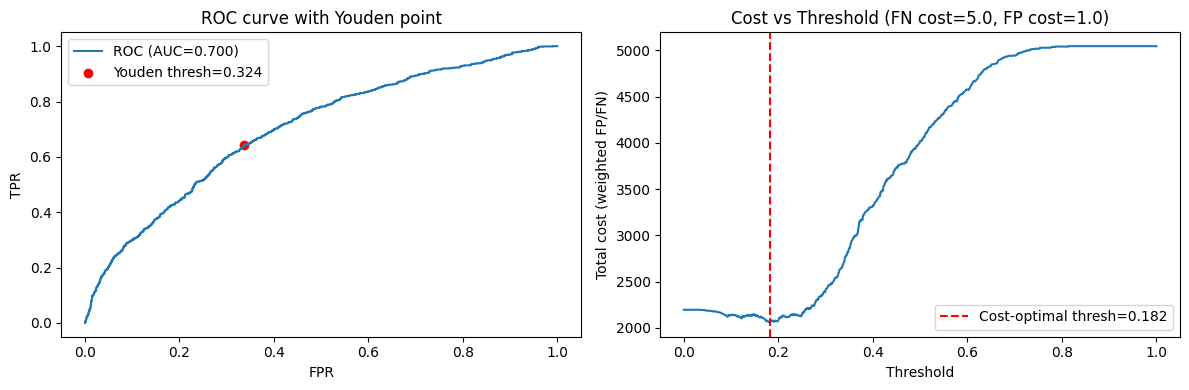

Youden (max TPR-FPR) threshold and metrics:
threshold                                                0.324412
sensitivity                                               0.64222
specificity                                              0.663326
confusion_matrix    {'tn': 1456, 'fp': 739, 'fn': 361, 'tp': 648}
dtype: object

Cost-based optimal threshold and metrics:
threshold                                                  0.182
sensitivity                                             0.910803
specificity                                             0.269704
confusion_matrix    {'tn': 592, 'fp': 1603, 'fn': 90, 'tp': 919}
total_cost                                                2053.0
cost_params                     {'cost_fn': 5.0, 'cost_fp': 1.0}
dtype: object

Confusion matrix at Youden threshold:
                  Pred Joiner(0)  Pred Renege(1)
Actual Joiner(0)            1456             739
Actual Renege(1)             361             648

Confusion matrix at Cost-optimal threshold:


In [16]:
# Compute optimal classification thresholds: Youden's J and cost-based minimization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score

# Robustly find a predicted-probability vector from commonly used names in this notebook
probs = None
for _name in ['y_pred_prob', 'probs_sklearn', 'probs', 'probs_sklearn', 'y_pred_prob_sk']:
    if _name in globals() and globals().get(_name) is not None:
        probs = globals().get(_name)
        break
if probs is None:
    raise RuntimeError('No predicted probabilities found (y_pred_prob, probs_sklearn, or probs). Run prediction cells first.')

# Youden's J
fpr_vals, tpr_vals, thr = roc_curve(Y_test, probs)
youden = tpr_vals - fpr_vals
ix = np.nanargmax(youden)
youden_thresh = thr[ix]
cm_you = confusion_matrix(Y_test, (probs >= youden_thresh).astype(int))
tn, fp, fn, tp = cm_you.ravel()

youden_results = {
    'threshold': float(youden_thresh),
    'sensitivity': float(tpr_vals[ix]),
    'specificity': float(1 - fpr_vals[ix]),
    'confusion_matrix': {'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)}
}

# Cost-based threshold (default costs: FN=5, FP=1). Adjust as needed.
cost_fn = 5.0
cost_fp = 1.0
thresholds = np.linspace(0.0, 1.0, 1001)
cost_vals = []
metrics_at_thresh = []
for t in thresholds:
    y_t = (probs >= t).astype(int)
    cm = confusion_matrix(Y_test, y_t)
    tn_, fp_, fn_, tp_ = cm.ravel()
    cost = cost_fn * fn_ + cost_fp * fp_
    cost_vals.append(cost)
    sens = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0.0
    spec = tn_ / (tn_ + fp_) if (tn_ + fp_) > 0 else 0.0
    metrics_at_thresh.append((t, sens, spec, tn_, fp_, fn_, tp_, cost))

min_idx = int(np.argmin(cost_vals))
cost_thresh = float(thresholds[min_idx])
(t_val, sens_val, spec_val, tn_c, fp_c, fn_c, tp_c, cost_c) = metrics_at_thresh[min_idx]

cost_results = {
    'threshold': cost_thresh,
    'sensitivity': float(sens_val),
    'specificity': float(spec_val),
    'confusion_matrix': {'tn': int(tn_c), 'fp': int(fp_c), 'fn': int(fn_c), 'tp': int(tp_c)},
    'total_cost': float(cost_c),
    'cost_params': {'cost_fn': cost_fn, 'cost_fp': cost_fp}
}

# Plots
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(fpr_vals, tpr_vals, label=f'ROC (AUC={roc_auc_score(Y_test, probs):.3f})')
plt.scatter(fpr_vals[ix], tpr_vals[ix], c='red', label=f"Youden thresh={youden_thresh:.3f}")
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve with Youden point')
plt.legend()

plt.subplot(1,2,2)
plt.plot(thresholds, cost_vals)
plt.axvline(cost_thresh, color='red', linestyle='--', label=f'Cost-optimal thresh={cost_thresh:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Total cost (weighted FP/FN)')
plt.title(f'Cost vs Threshold (FN cost={cost_fn}, FP cost={cost_fp})')
plt.legend()
plt.tight_layout()
plt.show()

# Display results
print('Youden (max TPR-FPR) threshold and metrics:')
print(pd.Series(youden_results))
print('\nCost-based optimal threshold and metrics:')
print(pd.Series(cost_results))

print('\nConfusion matrix at Youden threshold:')
print(pd.DataFrame(cm_you, index=['Actual Joiner(0)','Actual Renege(1)'], columns=['Pred Joiner(0)','Pred Renege(1)']))
print('\nConfusion matrix at Cost-optimal threshold:')
cm_cost = confusion_matrix(Y_test, (probs >= cost_thresh).astype(int))
print(pd.DataFrame(cm_cost, index=['Actual Joiner(0)','Actual Renege(1)'], columns=['Pred Joiner(0)','Pred Renege(1)']))

print(f"\nYouden -> Sensitivity: {youden_results['sensitivity']:.3f}, Specificity: {youden_results['specificity']:.3f}")
print(f"Cost -> Sensitivity: {cost_results['sensitivity']:.3f}, Specificity: {cost_results['specificity']:.3f}")

# Save variables for later use
youden_threshold = youden_thresh
cost_threshold = cost_thresh
youden_results_var = youden_results
cost_results_var = cost_results


In [17]:
# 1) Find threshold to reach target recall (60-70%) and compare to cost-optimal thresholds
from sklearn.metrics import roc_curve, confusion_matrix, classification_report, roc_auc_score
import numpy as np
import pandas as pd

# Ensure predicted probabilities are available (prefer model-specific names)
probs = None
if 'y_pred_prob' in globals() and globals().get('y_pred_prob') is not None:
    probs = globals()['y_pred_prob']
elif 'probs_sklearn' in globals() and globals().get('probs_sklearn') is not None:
    probs = globals()['probs_sklearn']
elif 'probs' in globals() and globals().get('probs') is not None:
    probs = globals()['probs']
else:
    raise RuntimeError('No predicted probabilities found (y_pred_prob, probs_sklearn, or probs). Run prediction cells first.')

# Compute ROC arrays
fpr_vals, tpr_vals, thr_vals = roc_curve(Y_test, probs, drop_intermediate=False)

# Target recalls to test
target_recalls = [0.6, 0.65, 0.7]
recall_results = []
for tr in target_recalls:
    idxs = [i for i,v in enumerate(tpr_vals) if v >= tr]
    if len(idxs) > 0:
        # pick threshold among these with highest specificity (lowest fpr)
        best_i = max(idxs, key=lambda i: 1 - fpr_vals[i])
        th = thr_vals[best_i]
        y_t = (probs >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(Y_test, y_t).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        recall_results.append({'target_recall': tr, 'threshold': float(th), 'sensitivity': float(sens), 'specificity': float(spec), 'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp)})
    else:
        recall_results.append({'target_recall': tr, 'threshold': None})

recall_df = pd.DataFrame(recall_results)
print('Thresholds achieving target recalls (choose threshold that maximizes specificity among candidates):')
display(recall_df)

# Choose preferred recall threshold (prefer 0.65, fallback to any available)
sel = recall_df.loc[recall_df['target_recall']==0.65]
if len(sel) and pd.notna(sel.iloc[0]['threshold']):
    recall_threshold = float(sel.iloc[0]['threshold'])
else:
    non_null = recall_df[recall_df['threshold'].notna()]
    recall_threshold = float(non_null.iloc[0]['threshold']) if len(non_null) else None

if recall_threshold is not None:
    print(f"Selected threshold to target ~65% recall: {recall_threshold:.3f}")
    y_rec = (probs >= recall_threshold).astype(int)
    print('\nConfusion matrix at selected recall-threshold:')
    print(confusion_matrix(Y_test, y_rec))
    print('\nClassification report:')
    print(classification_report(Y_test, y_rec, digits=4))
else:
    print('No threshold achieves the target recalls specified.')

# 2) Cost-optimization over FN weight (5) with FP cost = 1
cost_fp = 1.0
fn_weights = [5.0]
thresholds = np.linspace(0.0, 1.0, 1001)
cost_summary = []
for fn_w in fn_weights:
    cost_vals = []
    for t in thresholds:
        y_t = (probs >= t).astype(int)
        tn, fp, fn_, tp = confusion_matrix(Y_test, y_t).ravel()
        cost = fn_w * fn_ + cost_fp * fp
        cost_vals.append(cost)
    idx = int(np.argmin(cost_vals))
    best_t = float(thresholds[idx])
    y_best = (probs >= best_t).astype(int)
    tn, fp, fn_, tp = confusion_matrix(Y_test, y_best).ravel()
    sens = tp / (tp + fn_) if (tp + fn_) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    total_cost = float(cost_vals[idx])
    cost_summary.append({'fn_weight': fn_w, 'best_threshold': best_t, 'sensitivity': sens, 'specificity': spec, 'tn':int(tn),'fp':int(fp),'fn':int(fn_),'tp':int(tp),'total_cost': total_cost})
cost_df = pd.DataFrame(cost_summary)
print('\nCost-optimization results (lower total_cost preferred):')
display(cost_df)

# Save the cost-optimal threshold for fn_weight=5 (default) if present
if 5.0 in cost_df['fn_weight'].values:
    cost_opt_threshold = float(cost_df.loc[cost_df['fn_weight']==5.0, 'best_threshold'].iloc[0])
    print(f"\nCost-optimal threshold for FN weight=5: {cost_opt_threshold:.3f}")
    y_cost = (probs >= cost_opt_threshold).astype(int)
    print('\nConfusion matrix at cost-optimal threshold (FN=5):')
    print(confusion_matrix(Y_test, y_cost))
    print('\nClassification report:')
    print(classification_report(Y_test, y_cost, digits=4))
else:
    cost_opt_threshold = None

# Summary: recommend threshold depending on business objective
print('\nSummary recommendation:')
if recall_threshold is not None:
    print(f" - To achieve ~65% recall use threshold = {recall_threshold:.3f} (see metrics above)")
if cost_opt_threshold is not None:
    print(f" - Cost-optimized threshold (FN cost=5) = {cost_opt_threshold:.3f} (see metrics above)")
print(' - Choose the threshold that balances recall target and acceptable FP workload.')

Thresholds achieving target recalls (choose threshold that maximizes specificity among candidates):


,target_recall,threshold,sensitivity,specificity,tn,fp,fn,tp
0,0.60,0.336185,0.600595,0.696583,1529,666,403,606
1,0.65,0.319724,0.650149,0.649658,1426,769,353,656
2,0.70,0.299324,0.700694,0.599544,1316,879,302,707


Selected threshold to target ~65% recall: 0.320

Confusion matrix at selected recall-threshold:
[[1426  769]
 [ 353  656]]

Classification report:
              precision    recall  f1-score   support

           0     0.8016    0.6497    0.7177      2195
           1     0.4604    0.6501    0.5390      1009

    accuracy                         0.6498      3204
   macro avg     0.6310    0.6499    0.6283      3204
weighted avg     0.6941    0.6498    0.6614      3204


Cost-optimization results (lower total_cost preferred):


,fn_weight,best_threshold,sensitivity,specificity,tn,fp,fn,tp,total_cost
0,5.0,0.182,0.910803,0.269704,592,1603,90,919,2053.0



Cost-optimal threshold for FN weight=5: 0.182

Confusion matrix at cost-optimal threshold (FN=5):
[[ 592 1603]
 [  90  919]]

Classification report:
              precision    recall  f1-score   support

           0     0.8680    0.2697    0.4115      2195
           1     0.3644    0.9108    0.5205      1009

    accuracy                         0.4716      3204
   macro avg     0.6162    0.5903    0.4660      3204
weighted avg     0.7094    0.4716    0.4459      3204


Summary recommendation:
 - To achieve ~65% recall use threshold = 0.320 (see metrics above)
 - Cost-optimized threshold (FN cost=5) = 0.182 (see metrics above)
 - Choose the threshold that balances recall target and acceptable FP workload.


In [18]:
# Consolidated metrics summary after processing & transformations
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Determine available probability vectors (model -> probs) using globals().get()
prob_sources = []
_val = globals().get('y_pred_prob')
if _val is not None:
    prob_sources.append(('Statsmodels', _val))
_val = globals().get('probs_sklearn')
if _val is not None:
    prob_sources.append(('Sklearn', _val))
_val = globals().get('probs')
if _val is not None and ('Statsmodels' not in [p[0] for p in prob_sources]):
    prob_sources.append(('Probs', _val))

# Fallback: if nothing found, raise informative error
if len(prob_sources) == 0:
    raise RuntimeError('No predicted-probability vector found (y_pred_prob, probs_sklearn, or probs). Run prediction cells first.')

# Collect thresholds of interest (if available in namespace)
# Use a separate dict name so we don't overwrite any numeric `thresholds` array used elsewhere
thresholds_map = {'baseline_0.5': 0.5}
for name in ['recall_threshold','cost_opt_threshold','youden_threshold','cost_threshold']:
    val = globals().get(name)
    if val is not None:
        thresholds_map[name] = float(val)

# Gather model-level stats (pseudo R2, AIC/BIC) if available
logit_full = globals().get('logit_full')
final_logit = globals().get('final_logit')
pseudo_r2 = final_logit.prsquared if final_logit is not None else np.nan
aic_full = logit_full.aic if logit_full is not None else np.nan
aic_final = final_logit.aic if final_logit is not None else np.nan
bic_full = logit_full.bic if logit_full is not None else np.nan
bic_final = final_logit.bic if final_logit is not None else np.nan

rows = []
fn_cost = 5.0  # business weight used in cost-optimization

for model_name, probs in prob_sources:
    # AUC (if possible)
    try:
        auc = float(roc_auc_score(Y_test, probs))
    except Exception:
        auc = np.nan

    for thr_name, thr in thresholds_map.items():
        y_pred_thr = (probs >= thr).astype(int)
        try:
            tn, fp, fn, tp = confusion_matrix(Y_test, y_pred_thr).ravel()
        except Exception:
            tn = fp = fn = tp = 0
        acc = accuracy_score(Y_test, y_pred_thr) if len(Y_test)>0 else np.nan
        sens = recall_score(Y_test, y_pred_thr, zero_division=0)
        prec = precision_score(Y_test, y_pred_thr, zero_division=0)
        f1 = f1_score(Y_test, y_pred_thr, zero_division=0)
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        total_cost = fn_cost * fn + 1.0 * fp

        rows.append({
            'model': model_name,
            'threshold_name': thr_name,
            'threshold': thr,
            'accuracy': acc,
            'sensitivity': sens,
            'specificity': spec,
            'precision': prec,
            'f1': f1,
            'roc_auc': auc,
            'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
            'total_cost_fn5': total_cost,
            'pseudo_r2': pseudo_r2 if model_name=='Statsmodels' else np.nan,
            'aic_full': aic_full if model_name=='Statsmodels' else np.nan,
            'aic_final': aic_final if model_name=='Statsmodels' else np.nan,
            'bic_full': bic_full if model_name=='Statsmodels' else np.nan,
            'bic_final': bic_final if model_name=='Statsmodels' else np.nan
        })

metrics_df = pd.DataFrame(rows)
# Order columns for readability
cols = ['model','threshold_name','threshold','accuracy','sensitivity','specificity','precision','f1','roc_auc','tn','fp','fn','tp','total_cost_fn5','pseudo_r2','aic_full','aic_final','bic_full','bic_final']
metrics_df = metrics_df[cols]

print('Consolidated metrics summary (rows = model x threshold):')
# Round numeric columns for readability
metrics_display = metrics_df.round({
    'threshold': 3, 'accuracy': 4, 'sensitivity': 4, 'specificity': 4,
    'precision': 4, 'f1': 4, 'roc_auc': 4, 'total_cost_fn5': 0,
    'pseudo_r2': 4, 'aic_full': 2, 'aic_final': 2, 'bic_full': 2, 'bic_final': 2
})
display(metrics_display)

# Expose summary variables for downstream use
metrics_summary_df = metrics_df

print('\nSummary notes:\n - Rows show metrics for each available model (Statsmodels/Sklearn) at important thresholds.\n - Use `metrics_summary_df` for programmatic access in later cells.')

Consolidated metrics summary (rows = model x threshold):


,model,threshold_name,threshold,accuracy,sensitivity,specificity,precision,f1,roc_auc,tn,fp,fn,tp,total_cost_fn5,pseudo_r2,aic_full,aic_final,bic_full,bic_final
0,Statsmodels,baseline_0.5,0.500,0.7166,0.2289,0.9408,0.6399,0.3372,0.6995,2065,130,778,231,4020.0,0.0808,7918.92,8604.84,8195.69,8757.06
1,Statsmodels,recall_threshold,0.320,0.6498,0.6501,0.6497,0.4604,0.5390,0.6995,1426,769,353,656,2534.0,0.0808,7918.92,8604.84,8195.69,8757.06
2,Statsmodels,cost_opt_threshold,0.182,0.4716,0.9108,0.2697,0.3644,0.5205,0.6995,592,1603,90,919,2053.0,0.0808,7918.92,8604.84,8195.69,8757.06
3,Statsmodels,youden_threshold,0.324,0.6567,0.6422,0.6633,0.4672,0.5409,0.6995,1456,739,361,648,2544.0,0.0808,7918.92,8604.84,8195.69,8757.06
4,Statsmodels,cost_threshold,0.182,0.4716,0.9108,0.2697,0.3644,0.5205,0.6995,592,1603,90,919,2053.0,0.0808,7918.92,8604.84,8195.69,8757.06
5,Sklearn,baseline_0.5,0.500,0.6483,0.6630,0.6415,0.4595,0.5428,0.7003,1408,787,340,669,2487.0,NaN,NaN,NaN,NaN,NaN
6,Sklearn,recall_threshold,0.320,0.4566,0.9187,0.2442,0.3585,0.5157,0.7003,536,1659,82,927,2069.0,NaN,NaN,NaN,NaN,NaN
7,Sklearn,cost_opt_threshold,0.182,0.3383,0.9980,0.0351,0.3222,0.4872,0.7003,77,2118,2,1007,2128.0,NaN,NaN,NaN,NaN,NaN
8,Sklearn,youden_threshold,0.324,0.4632,0.9158,0.2551,0.3611,0.5179,0.7003,560,1635,85,924,2060.0,NaN,NaN,NaN,NaN,NaN
9,Sklearn,cost_threshold,0.182,0.3383,0.9980,0.0351,0.3222,0.4872,0.7003,77,2118,2,1007,2128.0,NaN,NaN,NaN,NaN,NaN



Summary notes:
 - Rows show metrics for each available model (Statsmodels/Sklearn) at important thresholds.
 - Use `metrics_summary_df` for programmatic access in later cells.


## Model Diagnostics & Interpretation
1. ROC Curve Analysis
2. Cost vs Threshold Curve  
3. Coefficient Interpretation

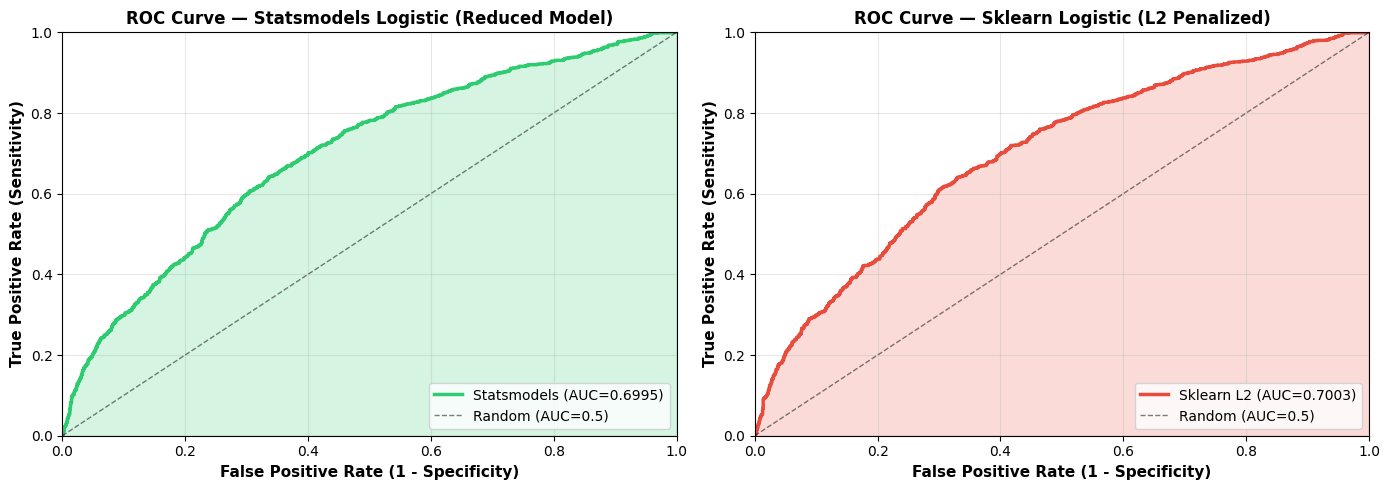


ROC Curve Interpretation:
--------------------------------------------------------------------------------
• Statsmodels AUC: 0.6995 — Model ranks renegers 70.0% better than random
• Sklearn AUC: 0.7003 — Penalized model ranks renegers 70.0% better than random
• AUC > 0.7: Fair discrimination | AUC > 0.8: Good | AUC > 0.9: Excellent
• The closer the curve hugs the top-left, the better the model discriminates between classes.
--------------------------------------------------------------------------------


In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC for Statsmodels (y_pred_prob)
if 'y_pred_prob' in globals() and y_pred_prob is not None:
    fpr_sm, tpr_sm, _ = roc_curve(Y_test, y_pred_prob)
    auc_sm = roc_auc_score(Y_test, y_pred_prob)
    
    axes[0].plot(fpr_sm, tpr_sm, color='#2ecc71', linewidth=2.5, label=f'Statsmodels (AUC={auc_sm:.4f})')
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.5)')
    axes[0].fill_between(fpr_sm, tpr_sm, alpha=0.2, color='#2ecc71')
    axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
    axes[0].set_title('ROC Curve — Statsmodels Logistic (Reduced Model)', fontsize=12, fontweight='bold')
    axes[0].legend(loc='lower right', fontsize=10)
    axes[0].grid(alpha=0.3)
    axes[0].set_xlim([0, 1])
    axes[0].set_ylim([0, 1])

# ROC for Sklearn (probs_sklearn)
if 'probs_sklearn' in globals() and probs_sklearn is not None:
    fpr_sk, tpr_sk, _ = roc_curve(Y_test, probs_sklearn)
    auc_sk = roc_auc_score(Y_test, probs_sklearn)
    
    axes[1].plot(fpr_sk, tpr_sk, color='#e74c3c', linewidth=2.5, label=f'Sklearn L2 (AUC={auc_sk:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.5)')
    axes[1].fill_between(fpr_sk, tpr_sk, alpha=0.2, color='#e74c3c')
    axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
    axes[1].set_title('ROC Curve — Sklearn Logistic (L2 Penalized)', fontsize=12, fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=10)
    axes[1].grid(alpha=0.3)
    axes[1].set_xlim([0, 1])
    axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\nROC Curve Interpretation:")
print("-" * 80)
# Safely print AUCs only if they were computed above
if 'auc_sm' in globals():
    try:
        print(f"• Statsmodels AUC: {auc_sm:.4f} — Model ranks renegers {auc_sm*100:.1f}% better than random")
    except Exception:
        print('Statsmodels AUC computed but could not be printed.')
if 'auc_sk' in globals():
    try:
        print(f"• Sklearn AUC: {auc_sk:.4f} — Penalized model ranks renegers {auc_sk*100:.1f}% better than random")
    except Exception:
        print('Sklearn AUC computed but could not be printed.')
if ('auc_sm' not in globals()) and ('auc_sk' not in globals()):
    print('No AUC values available to report (compute using Statsmodels or Sklearn probabilities).')
print(f"• AUC > 0.7: Fair discrimination | AUC > 0.8: Good | AUC > 0.9: Excellent")
print(f"• The closer the curve hugs the top-left, the better the model discriminates between classes.")
print("-" * 80)

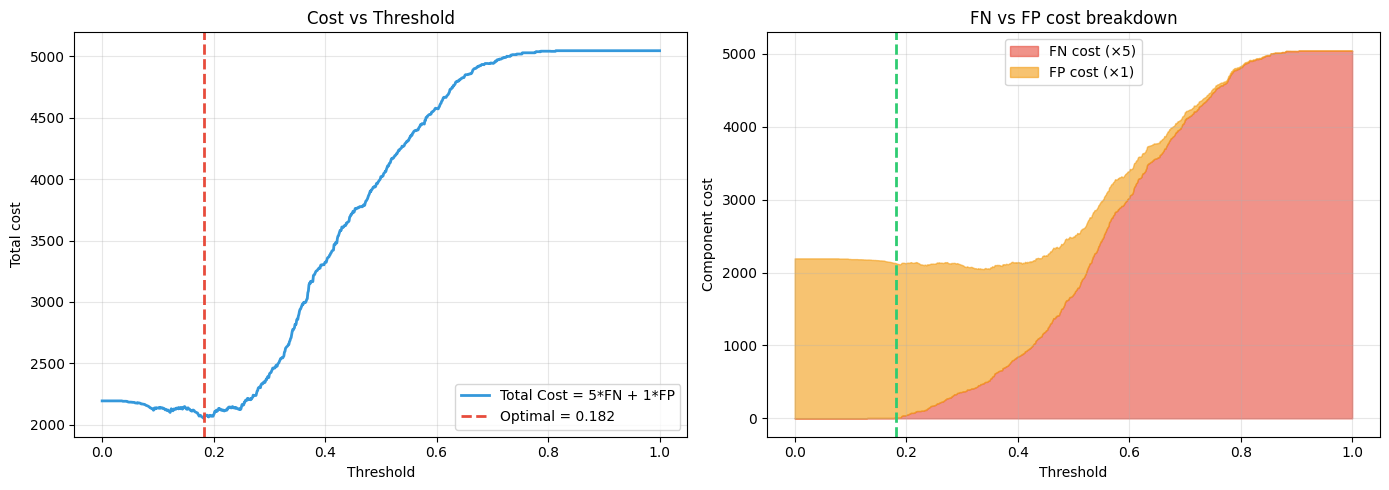

In [20]:
# Cost vs Threshold Curve (robust & simple)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Ensure required variables exist
if 'cost_vals' not in globals():
    raise RuntimeError("Missing 'cost_vals': run the threshold / cost search cell first.")

# Get cost_vals
cv = np.asarray(globals()['cost_vals'], dtype=float)

# Obtain thresholds; if not numeric or length mismatched, derive numeric linspace matching cost_vals
raw_th = globals().get('thresholds')
th = None
if raw_th is None:
    # try common alternative names
    raw_th = globals().get('thresholds_map') or globals().get('thresholds_dict')

# Helper to attempt conversion
def _try_array(o):
    try:
        return np.asarray(o, dtype=float)
    except Exception:
        return None

if raw_th is not None:
    th_candidate = _try_array(raw_th)
    if th_candidate is not None and th_candidate.size == cv.size:
        th = th_candidate
    else:
        # if raw_th is dict of named thresholds, ignore for continuous plot
        if isinstance(raw_th, dict):
            print("Note: 'thresholds' is a dict of named thresholds; deriving continuous thresholds from cost_vals length.")
        elif th_candidate is not None and th_candidate.size != cv.size:
            print(f"Warning: 'thresholds' length ({th_candidate.size}) != 'cost_vals' length ({cv.size}); deriving continuous thresholds.")

if th is None:
    th = np.linspace(0.0, 1.0, cv.size)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(th, cv, color='#3498db', linewidth=2.0, label='Total Cost = 5*FN + 1*FP')
if 'cost_opt_threshold' in globals() and globals().get('cost_opt_threshold') is not None:
    copt = float(globals()['cost_opt_threshold'])
    ax1.axvline(copt, color='#e74c3c', linestyle='--', linewidth=2, label=f'Optimal = {copt:.3f}')

ax1.set_xlabel('Threshold')
ax1.set_ylabel('Total cost')
ax1.set_title('Cost vs Threshold')
ax1.legend()
ax1.grid(alpha=0.3)

# Breakdown only if probabilities available (use explicit None checks to avoid array truthiness issues)
probs = None
for _name in ['probs', 'probs_sklearn', 'y_pred_prob']:
    if _name in globals() and globals().get(_name) is not None:
        probs = globals().get(_name)
        break

if probs is not None:
    fn_costs, fp_costs = [], []
    for t in th:
        y_t = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(Y_test, y_t).ravel()
        fn_costs.append(5.0 * fn)
        fp_costs.append(1.0 * fp)

    ax2.fill_between(th, 0, fn_costs, color='#e74c3c', alpha=0.6, label='FN cost (×5)')
    ax2.fill_between(th, fn_costs, np.array(fn_costs) + np.array(fp_costs), color='#f39c12', alpha=0.6, label='FP cost (×1)')
    if 'cost_opt_threshold' in globals() and globals().get('cost_opt_threshold') is not None:
        ax2.axvline(copt, color='#2ecc71', linestyle='--', linewidth=2)
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('Component cost')
    ax2.set_title('FN vs FP cost breakdown')
    ax2.legend()
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Probability vector not available\n(run prediction cells first)', ha='center', va='center')
    ax2.set_axis_off()

plt.tight_layout()
plt.show()

COEFFICIENT INTERPRETATION — UNDERSTANDING MODEL DRIVERS

1. STATSMODELS LOGISTIC REGRESSION (Reduced Model)
--------------------------------------------------------------------------------
Interpreting Log-Odds Coefficients:

                           Feature  Coefficient      P-Value Sig
                   Offered.band_E1    -1.289913 7.854343e-13 ***
                   Offered.band_E3    -1.205615 8.065518e-08 ***
                   Offered.band_E2    -1.088493 9.000236e-09 ***
                   long_acceptance    -0.725509 2.596723e-11 ***
Candidate.Source_Employee Referral    -0.630037 2.664687e-13 ***
                          exp_lt_3    -0.461468 9.261062e-08 ***
                         LOB_INFRA    -0.422079 2.206391e-07 ***
            Joining Location_Noida    -0.387408 1.545543e-08 ***
           Candidate.Source_Direct    -0.350459 4.445327e-09 ***
                    LOB_Healthcare    -0.334014 1.550565e-01  ns
                           LOB_ETS    -0.296372 6.122080e-

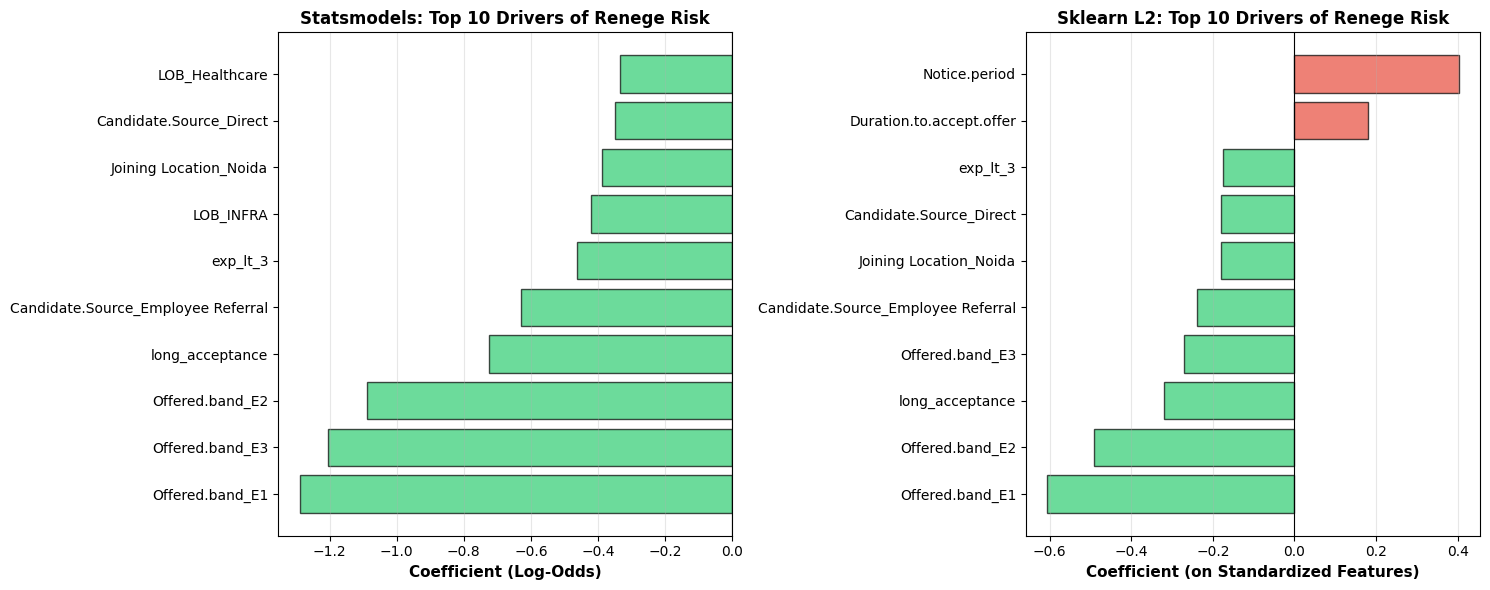


Key Takeaways:
────────────────────────────────────────────────────────────────────────────────
🔴 RED bars = Risk factors (positive coefficients) → increase renege probability
🟢 GREEN bars = Protective factors (negative coefficients) → decrease renege probability
📏 Bar length = Strength of effect on the model's decision
────────────────────────────────────────────────────────────────────────────────


In [21]:
# Coefficient Interpretation: What Drives Renege Risk?
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("COEFFICIENT INTERPRETATION — UNDERSTANDING MODEL DRIVERS")
print("="*80)

# === STATSMODELS COEFFICIENTS ===
if 'final_logit' in globals() and final_logit is not None:
    print("\n1. STATSMODELS LOGISTIC REGRESSION (Reduced Model)")
    print("-" * 80)
    print("Interpreting Log-Odds Coefficients:\n")
    
    coefs_sm = final_logit.params[1:]  # Exclude intercept
    pvals_sm = final_logit.pvalues[1:]
    
    # Create interpretation dataframe
    coef_table = pd.DataFrame({
        'Feature': coefs_sm.index,
        'Coefficient': coefs_sm.values,
        'P-Value': pvals_sm.values,
        'Sig': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns' for p in pvals_sm.values]
    })
    
    # Sort by absolute coefficient magnitude
    coef_table['Abs_Coef'] = np.abs(coef_table['Coefficient'])
    coef_table_sorted = coef_table.sort_values('Abs_Coef', ascending=False).drop('Abs_Coef', axis=1)
    
    print(coef_table_sorted.to_string(index=False))
    print("\n*** p<0.001 | ** p<0.01 | * p<0.05 | ns = not significant\n")
    
    print("Interpretation Guide:")
    print("├─ POSITIVE coefficient (+): Increases log-odds of reneging (risk factor)")
    print("├─ NEGATIVE coefficient (-): Decreases log-odds of reneging (protective factor)")
    print("├─ MAGNITUDE: Larger |coef| = stronger effect on decision boundary")
    print("└─ Statistical Significance: *** = strong evidence the feature matters\n")
    
    # Show top risk and protective factors
    print("Top 5 RISK FACTORS (increases renege probability):")
    top_risk = coef_table_sorted[coef_table_sorted['Coefficient'] > 0].head()
    for idx, row in top_risk.iterrows():
        odds_ratio = np.exp(row['Coefficient'])
        print(f"  • {row['Feature']:<30} Coef={row['Coefficient']:>7.4f}  (Odds Multiply by {odds_ratio:.3f}x) {row['Sig']}")
    
    print("\nTop 5 PROTECTIVE FACTORS (decreases renege probability):")
    top_protect = coef_table_sorted[coef_table_sorted['Coefficient'] < 0].head()
    for idx, row in top_protect.iterrows():
        odds_ratio = np.exp(row['Coefficient'])
        print(f"  • {row['Feature']:<30} Coef={row['Coefficient']:>7.4f}  (Odds Multiply by {odds_ratio:.3f}x) {row['Sig']}")

# === SKLEARN COEFFICIENTS ===
if 'clf' in globals() and clf is not None and 'num_cols' in globals():
    print("\n\n2. SKLEARN LOGISTIC REGRESSION (L2 Penalized)")
    print("-" * 80)
    print("Interpreting Coefficients (on Scaled Features):\n")
    
    coefs_sk = pd.Series(clf.coef_[0], index=num_cols).sort_values(key=abs, ascending=False)
    
    # Create interpretation table
    coef_sk_table = pd.DataFrame({
        'Feature': coefs_sk.index,
        'Coefficient': coefs_sk.values
    })
    
    print(coef_sk_table.to_string(index=False))
    
    print("\n\nInterpretation (on standardized features):")
    print("├─ POSITIVE coefficient: Higher feature value → Higher renege risk")
    print("├─ NEGATIVE coefficient: Higher feature value → Lower renege risk")
    print("├─ MAGNITUDE: |coef| ~ relative importance (features are scaled)")
    print("└─ L2 penalty shrinks coefficients to reduce overfitting\n")
    
    print("Top 5 RISK factors (Positive coefficients):")
    top_risk_sk = coefs_sk[coefs_sk > 0].head()
    for feat, val in top_risk_sk.items():
        print(f"  • {feat:<30} Coef={val:>7.4f}")
    
    print("\nTop 5 PROTECTIVE factors (Negative coefficients):")
    top_protect_sk = coefs_sk[coefs_sk < 0].head()
    for feat, val in top_protect_sk.items():
        print(f"  • {feat:<30} Coef={val:>7.4f}")

# === VISUALIZATION ===
print("\n\nVisualizing Top Coefficients...")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

if 'final_logit' in globals():
    # Statsmodels coefficients
    top_n = 10
    coef_plot = coef_table_sorted.head(top_n).copy()
    coef_plot['Color'] = ['#e74c3c' if x > 0 else '#2ecc71' for x in coef_plot['Coefficient']]
    
    axes[0].barh(range(len(coef_plot)), coef_plot['Coefficient'], color=coef_plot['Color'], alpha=0.7, edgecolor='black')
    axes[0].set_yticks(range(len(coef_plot)))
    axes[0].set_yticklabels(coef_plot['Feature'])
    axes[0].axvline(0, color='black', linestyle='-', linewidth=0.8)
    axes[0].set_xlabel('Coefficient (Log-Odds)', fontsize=11, fontweight='bold')
    axes[0].set_title('Statsmodels: Top 10 Drivers of Renege Risk', fontsize=12, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

if 'clf' in globals() and 'num_cols' in globals():
    # Sklearn coefficients
    coefs_sk_plot = coefs_sk.head(top_n).copy()
    coefs_sk_plot_sort = coefs_sk_plot.sort_values()
    colors_sk = ['#e74c3c' if x > 0 else '#2ecc71' for x in coefs_sk_plot_sort]
    
    axes[1].barh(range(len(coefs_sk_plot_sort)), coefs_sk_plot_sort, color=colors_sk, alpha=0.7, edgecolor='black')
    axes[1].set_yticks(range(len(coefs_sk_plot_sort)))
    axes[1].set_yticklabels(coefs_sk_plot_sort.index)
    axes[1].axvline(0, color='black', linestyle='-', linewidth=0.8)
    axes[1].set_xlabel('Coefficient (on Standardized Features)', fontsize=11, fontweight='bold')
    axes[1].set_title('Sklearn L2: Top 10 Drivers of Renege Risk', fontsize=12, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Takeaways:")
print("─" * 80)
print("🔴 RED bars = Risk factors (positive coefficients) → increase renege probability")
print("🟢 GREEN bars = Protective factors (negative coefficients) → decrease renege probability")
print("📏 Bar length = Strength of effect on the model's decision")
print("─" * 80)